# Lab Activity Sheet 2
## Quantum Programming using Cirq

## Pre-Lab Setup

In [1]:
import cirq
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot_bloch(bloch_vec, title=''):
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection='3d')
    u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
    x = np.cos(u) * np.sin(v)
    y = np.sin(u) * np.sin(v)
    z = np.cos(v)
    ax.plot_wireframe(x, y, z, color='lightgray', linewidth=0.5)
    ax.quiver(0, 0, 0, bloch_vec[0], bloch_vec[1], bloch_vec[2],
              color='red', linewidth=2, arrow_length_ratio=0.15)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title)
    plt.show()

## Activity 1: Qubits and State Vectors (25 minutes)

### Task 1.1 - The default qubit state

In [3]:
q = cirq.LineQubit(0)
sim = cirq.Simulator()

circuit1 = cirq.Circuit()
result1 = sim.simulate(circuit1, qubit_order=[q])
print(result1.final_state_vector)

[1.+0.j 0.+0.j]


### Task 1.2 - Creating superposition

In [4]:
circuit2 = cirq.Circuit(cirq.H(q))    # creates superposition
result2 = sim.simulate(circuit2, qubit_order=[q])
print(result2.final_state_vector)
print('Probabilities:', np.abs(result2.final_state_vector) ** 2)

[0.70710677+0.j 0.70710677+0.j]
Probabilities: [0.49999997 0.49999997]


### Task 1.3 - Initializing a custom qubit state

In [5]:
custom_state = np.array([1/np.sqrt(2), 1j/np.sqrt(2)], dtype=complex)
circuit3 = cirq.Circuit()
result3 = sim.simulate(circuit3, qubit_order=[q], initial_state=custom_state)
print(result3.final_state_vector)

[0.70710677+0.j         0.        +0.70710677j]


## Activity 2: Bloch Sphere Representation (20 minutes)

### Task 2.1 - Plotting basic states

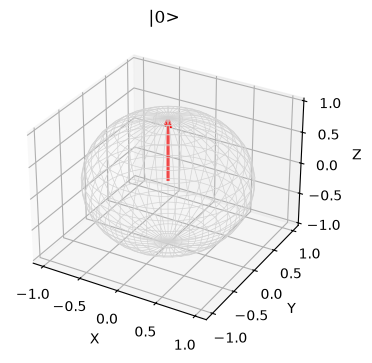

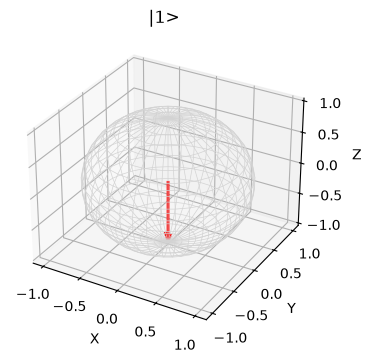

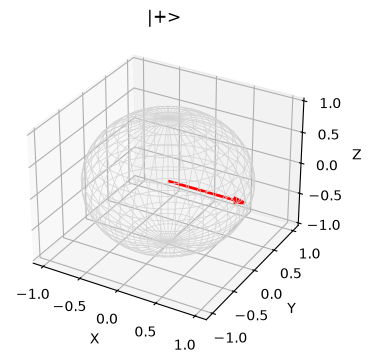

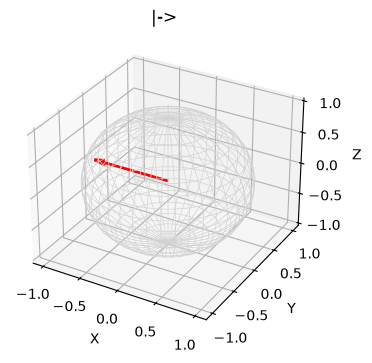

In [6]:
circuits = {
    '|0>': cirq.Circuit(),
    '|1>': cirq.Circuit(cirq.X(q)),
    '|+>': cirq.Circuit(cirq.H(q)),
    '|->': cirq.Circuit([cirq.X(q), cirq.H(q)]),
}

for name, circ in circuits.items():
    sv = sim.simulate(circ, qubit_order=[q]).final_state_vector
    vec = cirq.bloch_vector_from_state_vector(sv, 0)
    plot_bloch(vec, title=name)

### Task 2.2 - Gate action on the Bloch sphere

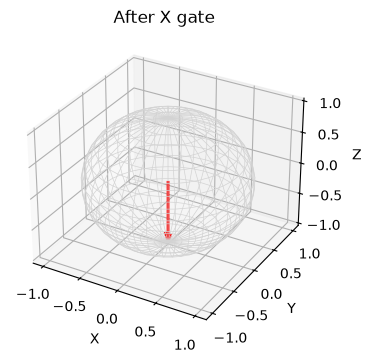

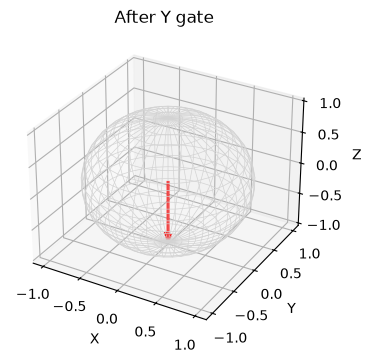

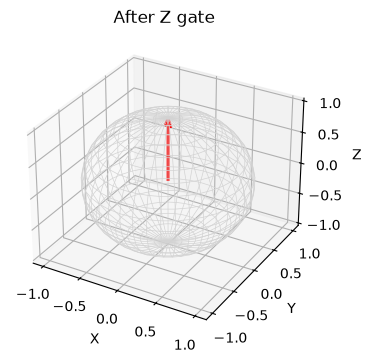

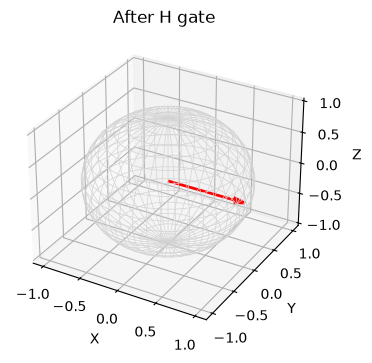

In [7]:
gates = {'X': cirq.X, 'Y': cirq.Y, 'Z': cirq.Z, 'H': cirq.H}
for name, gate in gates.items():
    circ = cirq.Circuit(gate(q))          # apply the gate to qubit q
    sv = sim.simulate(circ, qubit_order=[q]).final_state_vector
    vec = cirq.bloch_vector_from_state_vector(sv, 0)
    plot_bloch(vec, title=f'After {name} gate')

## Activity 3: Quantum Gates - Single-Qubit + CNOT (40 minutes)

### Task 3.1 - Single-qubit gate matrices and effects

In [8]:
single_gates = {
    'X': cirq.X, 'Y': cirq.Y, 'Z': cirq.Z,
    'H': cirq.H, 'S': cirq.S, 'T': cirq.T,
}
for name, gate in single_gates.items():
    print(name, 'matrix:')
    print(cirq.unitary(gate).round(3))
    circ = cirq.Circuit(gate(q))
    sv = sim.simulate(circ, qubit_order=[q]).final_state_vector
    print(name, 'applied to |0>:', sv.round(4))
    print('-' * 40)

X matrix:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
X applied to |0>: [0.+0.j 1.+0.j]
----------------------------------------
Y matrix:
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
Y applied to |0>: [0.+0.j 0.+1.j]
----------------------------------------
Z matrix:
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
Z applied to |0>: [ 1.+0.j -0.+0.j]
----------------------------------------
H matrix:
[[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
H applied to |0>: [0.7071+0.j 0.7071+0.j]
----------------------------------------
S matrix:
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
S applied to |0>: [1.+0.j 0.+0.j]
----------------------------------------
T matrix:
[[1.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]
T applied to |0>: [1.+0.j 0.+0.j]
----------------------------------------


### Task 3.2 - Gate identities

In [9]:
# (a) H applied twice should return the qubit to its starting state
circuit_hh = cirq.Circuit([cirq.H(q), cirq.H(q)])       # apply H a second time
print('H*H |0>  =', sim.simulate(circuit_hh, qubit_order=[q]).final_state_vector.round(4))

# (b) S applied twice should equal a single Z gate
circuit_ss = cirq.Circuit([cirq.S(q), cirq.S(q)])
print('S*S matrix ='); print(cirq.unitary(circuit_ss).round(3))

# (c) T applied twice should equal a single S gate
circuit_tt = cirq.Circuit([cirq.T(q), cirq.T(q)])
print('T*T matrix ='); print(cirq.unitary(circuit_tt).round(3))

# (d) Conjugating X by H (H X H) should equal Z
circuit_hxh = cirq.Circuit([cirq.H(q), cirq.X(q), cirq.H(q)])   # apply the final H
print('H*X*H matrix ='); print(cirq.unitary(circuit_hxh).round(3))

H*H |0>  = [ 1.+0.j -0.+0.j]
S*S matrix =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
T*T matrix =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
H*X*H matrix =
[[ 1.+0.j  0.+0.j]
 [-0.+0.j -1.+0.j]]


### Task 3.3 - Parametrized rotation gates RX, RY, RZ

In [10]:
angles = {'pi/2': np.pi/2, 'pi': np.pi}
for name, theta in angles.items():
    for gate_fn, gname in [(cirq.rx, 'RX'), (cirq.ry, 'RY'), (cirq.rz, 'RZ')]:
        circ = cirq.Circuit(gate_fn(theta)(q))
        sv = sim.simulate(circ, qubit_order=[q]).final_state_vector
        probs = np.abs(sv) ** 2
        print(f'{gname}({name}) |0> = {sv.round(4)}  probs={probs.round(4)}')

RX(pi/2) |0> = [0.7071+0.j     0.    -0.7071j]  probs=[0.5 0.5]
RY(pi/2) |0> = [0.7071+0.j 0.7071+0.j]  probs=[0.5 0.5]
RZ(pi/2) |0> = [0.7071-0.7071j 0.    +0.j    ]  probs=[1. 0.]
RX(pi) |0> = [0.+0.j 0.-1.j]  probs=[0. 1.]
RY(pi) |0> = [0.+0.j 1.+0.j]  probs=[0. 1.]
RZ(pi) |0> = [0.-1.j 0.+0.j]  probs=[1. 0.]


### Task 3.4 - The CNOT gate (two qubits)

In [11]:
q0, q1 = cirq.LineQubit.range(2)

for q0_val, q1_val in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    ops = []
    if q0_val: ops.append(cirq.X(q0))
    if q1_val: ops.append(cirq.X(q1))
    # q0 is the control qubit, q1 is the target qubit
    circuit = cirq.Circuit(ops + [cirq.CNOT(q0, q1)])
    result = sim.simulate(circuit, qubit_order=[q0, q1])
    print(f'Input |{q0_val}{q1_val}> -> Output {result.dirac_notation()}')

Input |00> -> Output |00⟩
Input |01> -> Output |01⟩
Input |10> -> Output |11⟩
Input |11> -> Output |10⟩


### Task 3.5 - Challenge: Building a Bell state

In [12]:
bell_circuit = cirq.Circuit([cirq.H(q0), cirq.CNOT(q0, q1)])
result = sim.simulate(bell_circuit, qubit_order=[q0, q1])
print(result.final_state_vector.round(4))
print(result.dirac_notation())

[0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
0.71|00⟩ + 0.71|11⟩


## Activity 4: Measurement (25 minutes)

### Task 4.1 - Measuring a superposition state

In [13]:
circuit_m = cirq.Circuit([cirq.H(q), cirq.measure(q, key='result')])
res = sim.run(circuit_m, repetitions=1024)
print(res.histogram(key='result'))

Counter({1: 533, 0: 491})


### Task 4.2 - Sweeping the rotation angle

In [14]:
thetas = {'0': 0, 'pi/4': np.pi/4, 'pi/2': np.pi/2, '3pi/4': 3*np.pi/4, 'pi': np.pi}
for label, theta in thetas.items():
    circuit = cirq.Circuit([cirq.ry(theta)(q), cirq.measure(q, key='result')])
    res = sim.run(circuit, repetitions=1024)
    hist = res.histogram(key='result')
    p1_sim = hist[1] / 1024
    p1_theory = np.sin(theta / 2) ** 2
    print(f'theta={label:5s} hist={dict(hist)}  '
          f'P(1)_sim={p1_sim:.3f}  P(1)_theory={p1_theory:.3f}')

theta=0     hist={0: 1024}  P(1)_sim=0.000  P(1)_theory=0.000
theta=pi/4  hist={0: 884, 1: 140}  P(1)_sim=0.137  P(1)_theory=0.146
theta=pi/2  hist={1: 524, 0: 500}  P(1)_sim=0.512  P(1)_theory=0.500
theta=3pi/4 hist={1: 883, 0: 141}  P(1)_sim=0.862  P(1)_theory=0.854
theta=pi    hist={1: 1024}  P(1)_sim=1.000  P(1)_theory=1.000


### Task 4.3 - Ideal probabilities vs. simulated counts

In [15]:
circuit_plus = cirq.Circuit([cirq.H(q), cirq.measure(q, key='result')])
for shots in [100, 1024, 8192]:
    res = sim.run(circuit_plus, repetitions=shots)
    print(f'shots={shots}:', dict(res.histogram(key='result')))

shots=100: {1: 48, 0: 52}
shots=1024: {1: 529, 0: 495}
shots=8192: {1: 4191, 0: 4001}


### Task 4.4 - Measuring the Bell state

In [16]:
import collections

bell_m = cirq.Circuit([
    cirq.H(q0), cirq.CNOT(q0, q1), cirq.measure(q0, q1, key='result')
])
res = sim.run(bell_m, repetitions=1024)
bits = res.measurements['result']
strs = [''.join(str(b) for b in row) for row in bits]
print(collections.Counter(strs))

Counter({'00': 529, '11': 495})
